#**Prediction Project: California Housing Dataset**

In [101]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt #These libs are necessary to make EDA. More forward maybe we need to use some extra libs and we can import it later

In [102]:
data = pd.read_csv('/content/sample_data/california_housing_train.csv')

In [103]:
data.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
5,-114.58,33.63,29.0,1387.0,236.0,671.0,239.0,3.3438,74000.0
6,-114.58,33.61,25.0,2907.0,680.0,1841.0,633.0,2.6768,82400.0
7,-114.59,34.83,41.0,812.0,168.0,375.0,158.0,1.7083,48500.0
8,-114.59,33.61,34.0,4789.0,1175.0,3134.0,1056.0,2.1782,58400.0
9,-114.60,34.83,46.0,1497.0,309.0,787.0,271.0,2.1908,48100.0


#**EDA**

**A key information to this dataset analysis, is that each row is the information of blocks of census, and isnt about a single house. The minimal geographic unity is a block.This clarify the initial idea of some houses with 5000 rooms.**

id: Unique identification by location

latitude and longitude: Geo pointer to its exactly location on earth

house_median_age: Median age int eh block

total_rooms: Total rooms in the block

total_bedrooms: Total bedrooms in the blobk

population: Total population in the block

households: Total houses in tle block

median_income: Median person income in dollars in the block (tens of thousands per year)

**Median_house_value**: Median house value in the block (**TARGET VALUE**)

In [104]:
data.describe(include='all')

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Using .describe we know:

There is 17.000 rows

There is outliers in some columns (like total rooms and total bedrooms, where there is a house with 2 rooms and one house with one bedroom(probaly this two values is from the same block, where there is ony one house)). Also there is outliers from above normal distribution (block with 1 as the median age, population above 35.000).

In [105]:
data.dtypes

,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64


In [106]:
!pip install sweetviz
import sweetviz as sw

In [107]:
#Solving class error between sw and np
if not hasattr(np, 'VisibleDeprecationWarning'):
    class VisibleDeprecationWarning(UserWarning):
        pass
    np.VisibleDeprecationWarning = VisibleDeprecationWarning

analysis = sw.analyze(data)
analysis.show_html('SWEETVIZ_REPORT.html')

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Using sw, I can analyze normal distribution, means, min and max values, correlation. In median age, we see that most part of blocks (6.2%) have 52 as the median age.

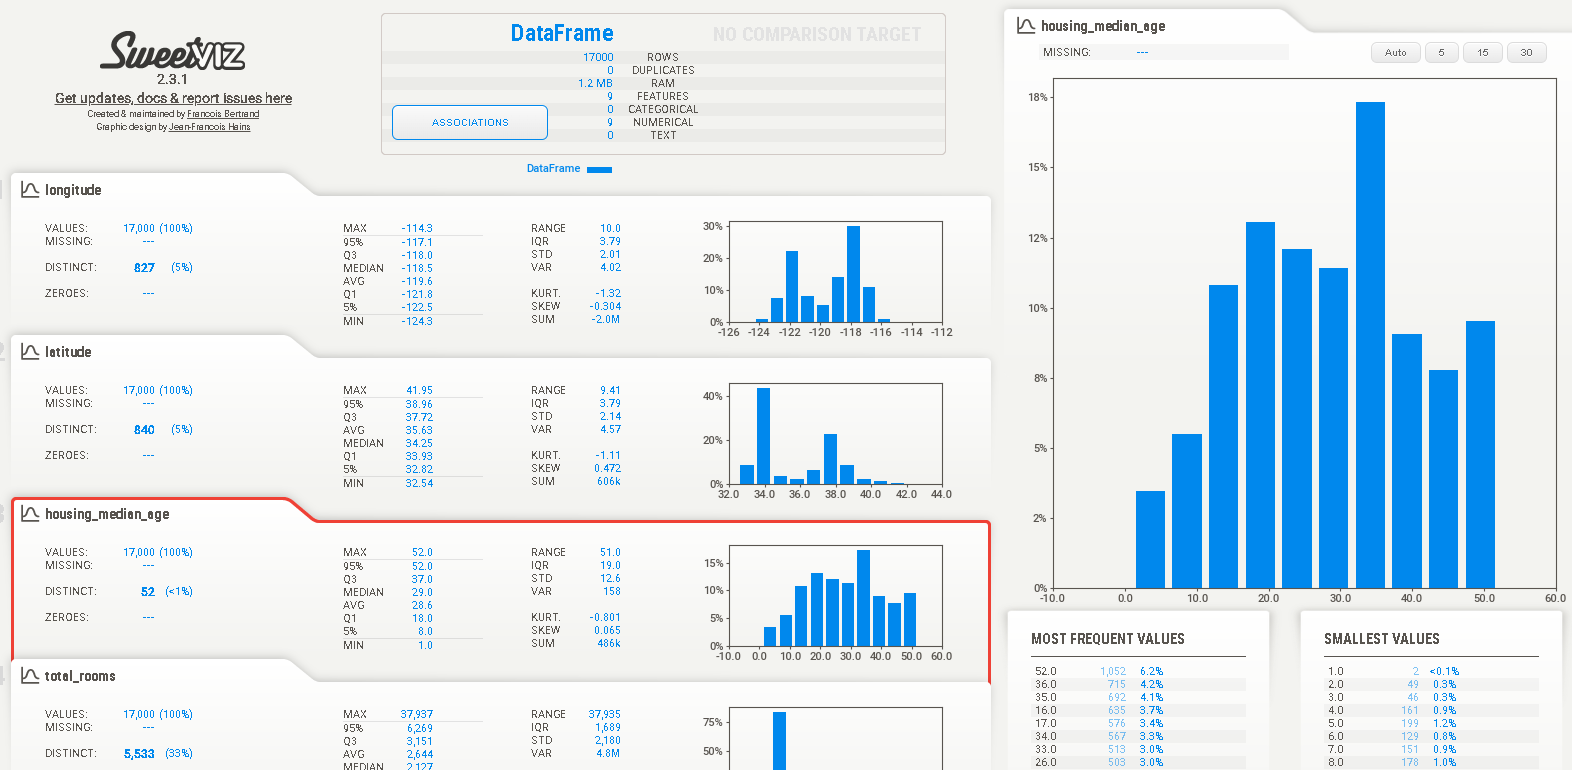

In total rooms column, we see a strong positive correlation with total_bedrooms, population and households. This correlation is self-explained.

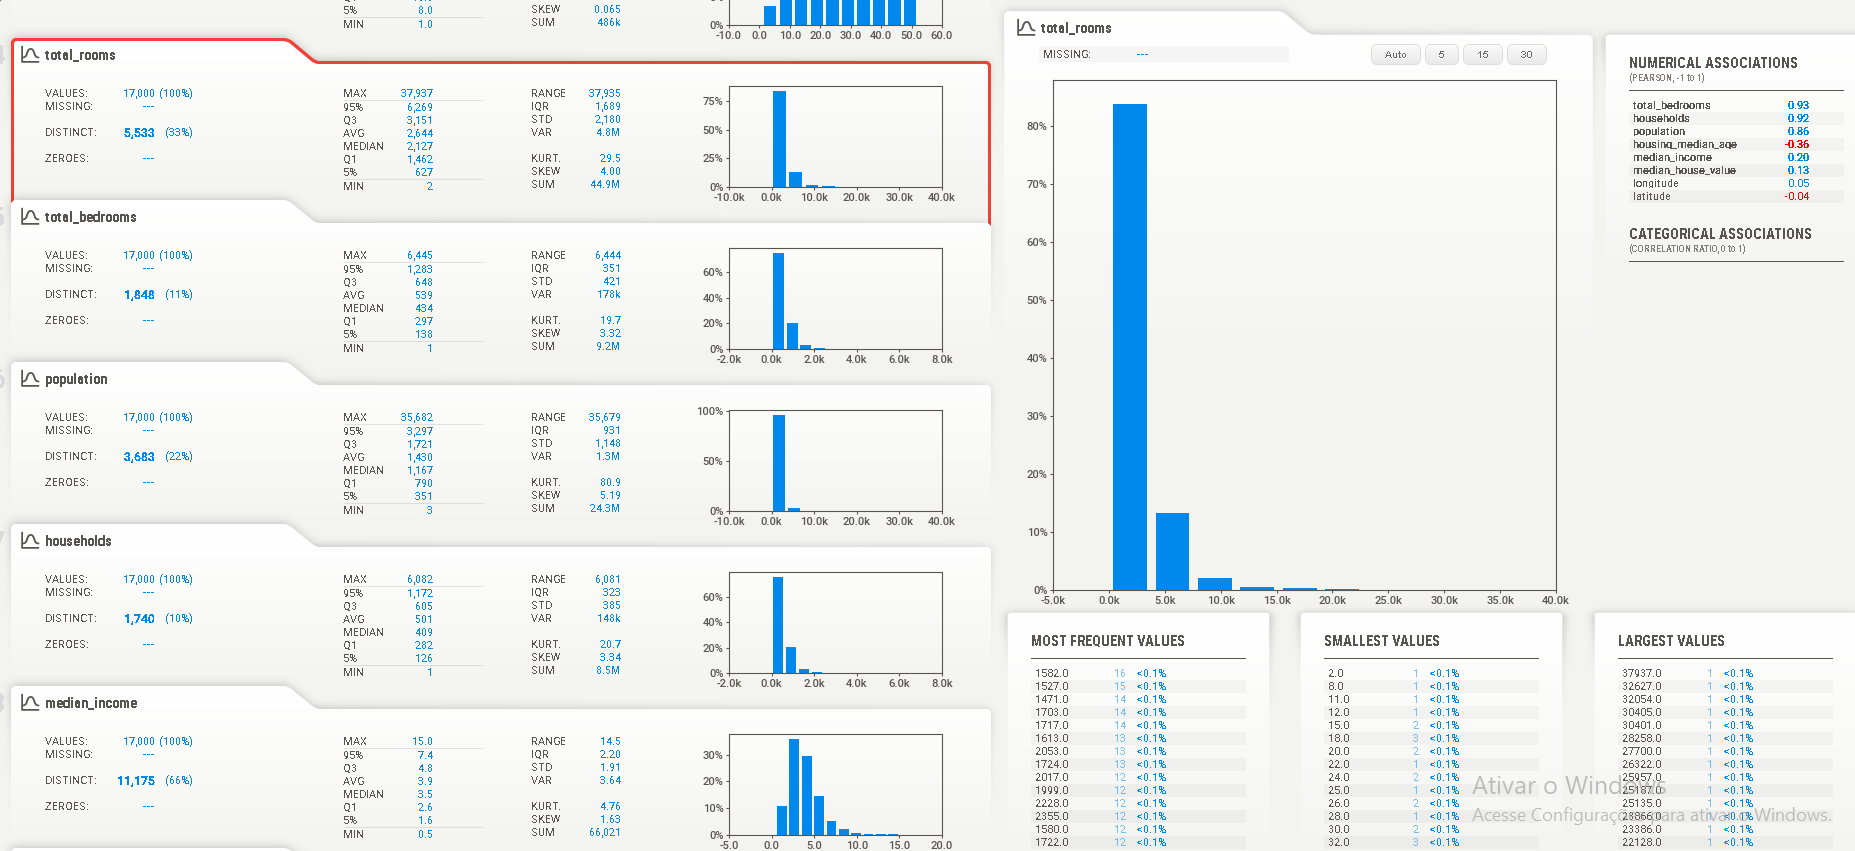

To a better viz of correlation, we can do a heatmap correlation with numpy and plt

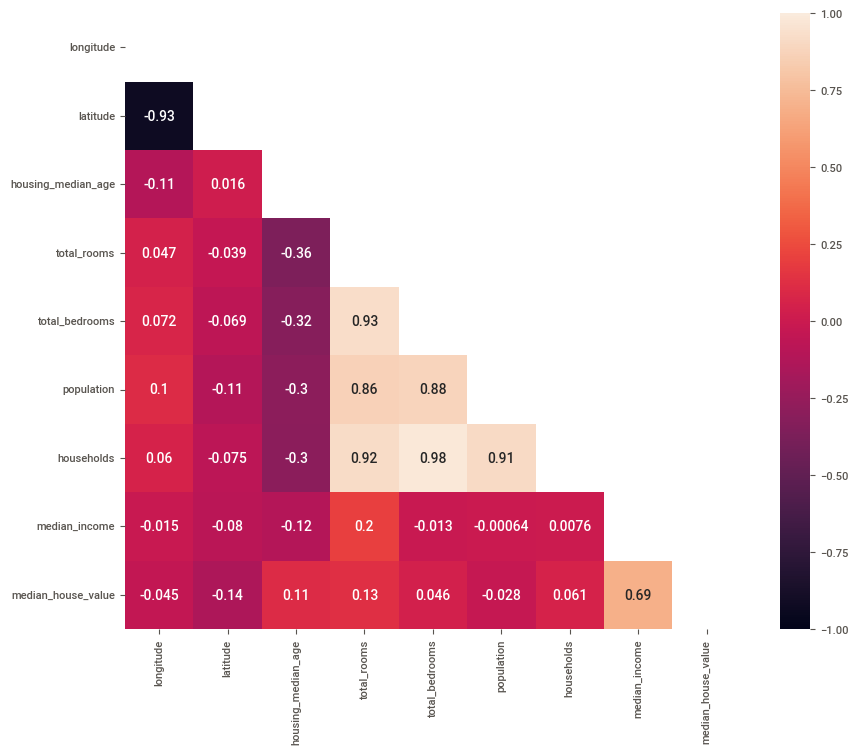

In [108]:
mask = (np.triu(np.ones_like(data.corr(), dtype=np.bool())))
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), mask=mask, square=True, annot=True, vmin=-1, vmax=1)
plt.show()

With that correlation map, we can see:

With more households, population tends to grow. Also households and population, are positive correlated with total bedrooms total rooms.

Also we can see that, in blocks with greater median income, the house values is also higher.

#**Starting ML**

This dataset is already pre-processed, so there is no things to pre-process

In [109]:
#splitting target and other data
y = data.median_house_value
X = data.drop('median_house_value', axis=1)
features = X.columns #Here we set a features variable, to make easier to set all features back if we need later in ds process

In [110]:
y

,median_house_value
0,66900.0
1,80100.0
2,85700.0
3,73400.0
4,65500.0
...,...
16995,111400.0
16996,79000.0
16997,103600.0
16998,85800.0


In [111]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250
...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797


In [112]:
features

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')

In [113]:
from sklearn.neighbors import KNeighborsRegressor #Here we using a KNN regressor model because we dont have a classified target (we have float/integer numbers). Later we
#can create a balanced measure gaving integer grades based on row numbers, and use its as a classifier

model = KNeighborsRegressor(3) #KNN = 3

**Training model**

In [114]:
model.fit(X, y) #First we pass tha data, after target value

KNeighborsRegressor(n_neighbors=3)

When I train the model using X and data, i dont alter nothing in theses variable, i only train the model

In [115]:
data.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [116]:
X.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250


In [117]:
model.predict(X.head(5))

array([121966.66666667, 176900.        , 148066.66666667, 106700.        ,
       134300.        ])

Here we see that the model is almost duplicating the target value predict for the first 5 lines(Original values: 66900,80100,85700,74300 and 65500 vs model predict values: 121966, 176900, 148066, 106700 and 134300)

In [118]:
data.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


**Evaluating model accuracy**

Here, we use a type of metric to evaluate model accuracy based on a subtration calculation of model prediction value for the row target - actual row target value

In [119]:
from sklearn.metrics import mean_absolute_error

In [120]:
prediction = model.predict(X) #Prediction for all rows (17.000)

In [121]:
prediction

array([121966.66666667, 176900.        , 148066.66666667, ...,
       106666.66666667, 128833.33333333, 252233.66666667])

In [122]:
mean_absolute_error(y, prediction) #Correct value - predicted value

55582.95749019608

That value from mean_absolute_error says to us that the model is off by an average of 55582. That value is way far from the correct value, so we need to adjust the model

In [123]:
data2 = pd.DataFrame(y)

In [124]:
data2['prediction'] = prediction

In [125]:
data2['difference'] = data2.median_house_value - data2.prediction

In [126]:
data2.sample(10) #using .sample to choose random rows

,median_house_value,prediction,difference
3874,210900.0,292666.666667,-81766.666667
10352,290900.0,210300.000000,80600.000000
12801,178500.0,167366.666667,11133.333333
5611,230900.0,223166.666667,7733.333333
3892,225200.0,181600.000000,43600.000000
11816,153900.0,275500.000000,-121600.000000
1055,298100.0,302033.333333,-3933.333333
7061,206300.0,162233.333333,44066.666667
10404,68600.0,99233.333333,-30633.333333
4222,178100.0,178166.666667,-66.666667


In [127]:
data2.describe()

,median_house_value,prediction,difference
count,17000.000000,17000.000000,17000.000000
mean,207300.912353,207369.360078,-68.447725
std,115983.764387,88609.781215,73091.980406
min,14999.000000,38166.333333,-298267.333333
25%,119400.000000,143533.333333,-45000.000000
50%,180400.000000,186300.000000,-1500.000000
75%,265000.000000,253575.250000,42166.666667
max,500001.000000,500001.000000,286467.333333


With that, we see that our means are SO CLOSE but we saw that the model error in values was big. With that describe we can see that the min was almost twice

In [128]:
model = KNeighborsRegressor(7) #KNN = 7

In [129]:
model.fit(X, y)

KNeighborsRegressor(n_neighbors=7)

In [130]:
model.predict(X.head(5))

array([113671.42857143, 220957.14285714, 132700.        , 211886.        ,
       150714.28571429])

#**Train and Test Validation**

In [131]:
from sklearn.model_selection import train_test_split

In [132]:
train_X, test_X , train_y, test_y = train_test_split(X, y, random_state=1, train_size=0.8) #Here we use a variable to train and another to test for target and values. Also, we use
# 80% to train, and 20% to test

In [133]:
train_X.shape #Here we see that ou train variable dont have 17.000 rows, because we no using the entire dataset as train variable

(13600, 8)

In [134]:
model2 = KNeighborsRegressor(3)

In [135]:
model2.fit(train_X, train_y)

KNeighborsRegressor(n_neighbors=3)

In [136]:
prediction2 = model2.predict(test_X) #Here we use all left rows to predict the model. This is useful because its simulate a real scenario with new data

**Validation from the model**

In [137]:
mean_absolute_error(test_y, prediction2) #Here we see that our model lost accuracy because we used new data to test prediction instead of the same data used in training

81475.73088235295

#**Using Decision Three Algorithm**

In [138]:
from sklearn.tree import DecisionTreeRegressor

In [139]:
tree_model = DecisionTreeRegressor(random_state=1, min_samples_leaf=15)

In [140]:
tree_model.fit(X, y)

DecisionTreeRegressor(min_samples_leaf=15, random_state=1)

In [141]:
tree_prediction = tree_model.predict(X)

In [142]:
mean_absolute_error(y, tree_prediction) #Here we see a significant improvement, even when both  algorithms is regressors

30824.120657959214

**Splitting train**

In [143]:
tree_model.fit(X, y) #Training with the 80%

DecisionTreeRegressor(min_samples_leaf=15, random_state=1)

In [144]:
tree_prediction = tree_model.predict(X) #Testing with the 20%

In [145]:
mean_absolute_error(y, tree_prediction) #Comparing the results between the prediction to 20% and the actual real value. We see here a improvement compared to the previous
#result when we splot

30824.120657959214

**Switching parameters from model**

In [146]:
tree_model2 = DecisionTreeRegressor(random_state=1, max_depth=8)

In [147]:
tree_model2.fit(train_X, train_y)

DecisionTreeRegressor(max_depth=8, random_state=1)

In [148]:
tree_prediction2 = rf_model2.predict(test_X)

In [149]:
mean_absolute_error(test_y, tree_prediction2)

39487.89821295996

#**Using Random Forest**

In [150]:
from sklearn.ensemble import RandomForestRegressor

In [151]:
rf_model = RandomForestRegressor(random_state=1, n_jobs=1, n_estimators=200)

In [152]:
rf_model.fit(train_X, train_y)

RandomForestRegressor(n_estimators=200, n_jobs=1, random_state=1)

In [153]:
rf_prediction = rf_model.predict(test_X)

In [154]:
mean_absolute_error(test_y, rf_prediction) #The best result from all algorithms, even when we already trained it with split logic

31134.331648529413

**Using 500 trees**

In [155]:
from sklearn.ensemble import RandomForestRegressor

In [156]:
rf_model2 = RandomForestRegressor(random_state=1, n_jobs=1, n_estimators=500)

In [157]:
rf_model2.fit(train_X, train_y)

RandomForestRegressor(n_estimators=500, n_jobs=1, random_state=1)

In [158]:
rf_prediction2 = rf_model2.predict(test_X)

In [159]:
mean_absolute_error(test_y, rf_prediction2) #Using 500 trees, we see a slightly improvement

31058.257090000003